# Encoding Data Visualization

This notebook visualizes the **encoded dataset** (`data/encoded_data.csv`) produced by `src/preprocessing/encode.py`.

The goal is to verify this preprocessing phase only:

- `tr_status` is converted to binary labels: `passed = 0`, failure states = `1`
- `gh_lang` is label-encoded
- Boolean columns are converted to `0/1`
- Canceled/unmapped target rows are removed

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
pd.set_option('display.max_columns', 100)

## 2. Load Encoded Data

In [2]:
data_path = '../data/encoded_data.csv'

# Use a sample for fast notebook visualization on normal laptops.
df = pd.read_csv(data_path, nrows=250_000, low_memory=False)

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Shape: 250,000 rows x 56 columns


,gh_project_name,gh_is_pr,gh_pr_created_at,gh_pull_req_num,gh_lang,git_merged_with,git_branch,git_prev_commit_resolution_status,tr_prev_build,gh_team_size,git_num_all_built_commits,gh_num_issue_comments,gh_num_commit_comments,gh_num_pr_comments,git_diff_src_churn,git_diff_test_churn,gh_diff_files_added,gh_diff_files_deleted,gh_diff_files_modified,gh_diff_tests_added,gh_diff_tests_deleted,gh_diff_src_files,gh_diff_doc_files,gh_diff_other_files,gh_num_commits_on_files_touched,gh_sloc,gh_test_lines_per_kloc,gh_test_cases_per_kloc,gh_asserts_cases_per_kloc,gh_by_core_team_member,gh_build_started_at,gh_repo_age,gh_repo_num_commits,tr_build_number,tr_log_lan,tr_log_status,tr_log_analyzer,tr_log_frameworks,tr_log_bool_tests_ran,tr_log_bool_tests_failed,tr_log_num_tests_ok,tr_log_num_tests_failed,tr_log_num_tests_run,tr_log_num_tests_skipped,tr_log_testduration,tr_duration,tr_status,hour_of_day,day_of_week,is_weekend,total_code_churn,test_to_src_ratio,total_files_changed,is_large_commit,test_fail_ratio,project_failure_rate
0,rspec/rspec-core,0,unknown,0.0,3,unknown,master,merge_found,0.0,31,202,0.0,0,0.0,117,0,34,6,137,0,0,3,0,148,817,3094,1539.431157,163.865546,225.921138,0,2011-04-16 11:24:39,655.82,1139,23,ruby,unknown,ruby,rspec#cucumber,1,False,800.0,0.0,800.0,2.0,114.83,956.0,0,11,5,1,117,0.0,177,1,0.0,0.0
1,rspec/rspec-core,0,unknown,0.0,3,unknown,master,merge_found,0.0,31,202,0.0,0,0.0,117,0,34,6,137,0,0,3,0,148,817,3094,1539.431157,163.865546,225.921138,0,2011-04-16 11:24:39,655.82,1139,23,ruby,unknown,ruby,rspec#cucumber,1,False,800.0,0.0,800.0,2.0,171.37,956.0,0,11,5,1,117,0.0,177,1,0.0,0.0
2,rspec/rspec-core,0,unknown,0.0,3,unknown,master,merge_found,0.0,31,202,0.0,0,0.0,117,0,34,6,137,0,0,3,0,148,817,3094,1539.431157,163.865546,225.921138,0,2011-04-16 11:24:39,655.82,1139,23,ruby,unknown,ruby,rspec#cucumber,1,False,800.0,0.0,800.0,2.0,177.02,956.0,0,11,5,1,117,0.0,177,1,0.0,0.0
3,rspec/rspec-core,0,unknown,0.0,3,unknown,master,merge_found,0.0,31,202,0.0,0,0.0,117,0,34,6,137,0,0,3,0,148,817,3094,1539.431157,163.865546,225.921138,0,2011-04-16 11:24:39,655.82,1139,23,ruby,unknown,ruby,rspec#cucumber,1,False,800.0,0.0,800.0,2.0,182.05,956.0,0,11,5,1,117,0.0,177,1,0.0,0.0
4,rspec/rspec-core,0,unknown,0.0,3,unknown,master,merge_found,0.0,31,202,0.0,0,0.0,117,0,34,6,137,0,0,3,0,148,817,3094,1539.431157,163.865546,225.921138,0,2011-04-16 11:24:39,655.82,1139,23,ruby,unknown,ruby,rspec#cucumber,1,False,800.0,0.0,800.0,2.0,113.26,956.0,0,11,5,1,117,0.0,177,1,0.0,0.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 56 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   gh_project_name                    250000 non-null  str    
 1   gh_is_pr                           250000 non-null  int64  
 2   gh_pr_created_at                   250000 non-null  str    
 3   gh_pull_req_num                    250000 non-null  float64
 4   gh_lang                            250000 non-null  int64  
 5   git_merged_with                    250000 non-null  str    
 6   git_branch                         250000 non-null  str    
 7   git_prev_commit_resolution_status  250000 non-null  str    
 8   tr_prev_build                      250000 non-null  float64
 9   gh_team_size                       250000 non-null  int64  
 10  git_num_all_built_commits          250000 non-null  int64  
 11  gh_num_issue_comments              250000 non-null

## 3. Encoding Validation

In [4]:
target_values = sorted(df['tr_status'].dropna().unique().tolist())
language_values = sorted(df['gh_lang'].dropna().unique().tolist())

bool_columns = [
    'gh_is_pr',
    'gh_by_core_team_member',
    'tr_log_bool_tests_ran',
    'is_weekend',
    'is_large_commit',
]
existing_bool_columns = [col for col in bool_columns if col in df.columns]
bool_value_check = {
    col: sorted(df[col].dropna().unique().tolist())
    for col in existing_bool_columns
}

print('Target values:', target_values)
print('gh_lang encoded values:', language_values)
print('Boolean value check:')
for col, values in bool_value_check.items():
    print(f'  {col}: {values}')

Target values: [0, 1]
gh_lang encoded values: [0, 1, 2, 3]
Boolean value check:
  gh_is_pr: [0, 1]
  gh_by_core_team_member: [0, 1]
  tr_log_bool_tests_ran: [0, 1]
  is_weekend: [0, 1]
  is_large_commit: [0, 1]


In [5]:
validation_summary = pd.DataFrame({
    'check': [
        'target_is_binary',
        'gh_lang_is_numeric',
        'booleans_are_0_1',
    ],
    'passed': [
        set(target_values).issubset({0, 1}),
        pd.api.types.is_numeric_dtype(df['gh_lang']),
        all(set(values).issubset({0, 1}) for values in bool_value_check.values()),
    ],
})

validation_summary

,check,passed
0,target_is_binary,True
1,gh_lang_is_numeric,True
2,booleans_are_0_1,True


## 4. Target Distribution

In [6]:
target_counts = df['tr_status'].value_counts().sort_index()
target_percent = (target_counts / target_counts.sum() * 100).round(2)

target_summary = pd.DataFrame({
    'label': ['passed (0)' if idx == 0 else 'failed/broken/errored (1)' for idx in target_counts.index],
    'count': target_counts.values,
    'percent': target_percent.values,
})

target_summary

,label,count,percent
0,passed (0),163969,65.59
1,failed/broken/errored (1),86031,34.41


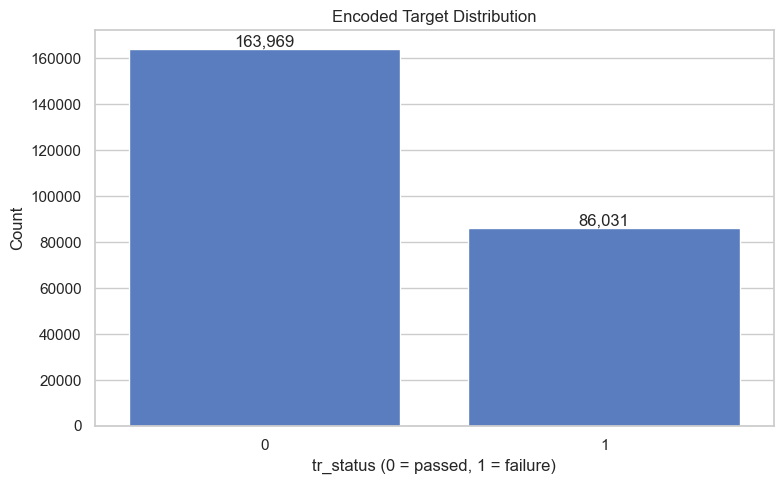

In [7]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='tr_status', order=[0, 1])
ax.set_title('Encoded Target Distribution')
ax.set_xlabel('tr_status (0 = passed, 1 = failure)')
ax.set_ylabel('Count')

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')

plt.tight_layout()
plt.show()

## 5. Language Encoding

In [8]:
# Mapping used by src/preprocessing/encode.py on the current dataset:
# {'go': 0, 'java': 1, 'python': 2, 'ruby': 3}
language_names = {
    0: 'go',
    1: 'java',
    2: 'python',
    3: 'ruby',
}

language_counts = df['gh_lang'].value_counts().sort_index()
language_summary = pd.DataFrame({
    'gh_lang_encoded': language_counts.index,
    'language': [language_names.get(value, 'unknown') for value in language_counts.index],
    'count': language_counts.values,
    'percent': (language_counts.values / language_counts.sum() * 100).round(2),
})

language_summary

,gh_lang_encoded,language,count,percent
0,0,go,2089,0.84
1,1,java,11620,4.65
2,2,python,60082,24.03
3,3,ruby,176209,70.48


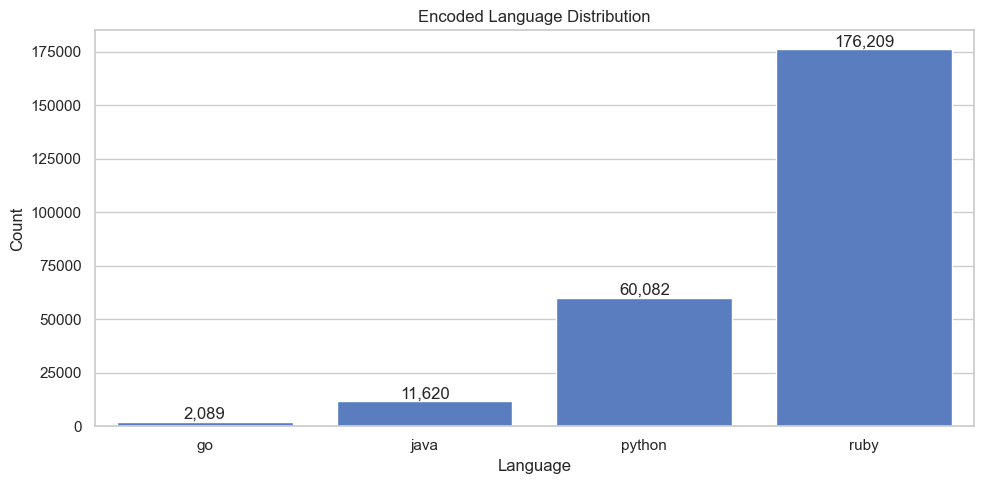

In [9]:
plot_df = language_summary.copy()

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=plot_df, x='language', y='count')
ax.set_title('Encoded Language Distribution')
ax.set_xlabel('Language')
ax.set_ylabel('Count')

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')

plt.tight_layout()
plt.show()

## 6. Target Rate by Encoded Language

In [10]:
language_target = (
    df.assign(language=df['gh_lang'].map(language_names).fillna('unknown'))
      .groupby('language')['tr_status']
      .agg(total='count', failure_rate='mean')
      .reset_index()
      .sort_values('failure_rate', ascending=False)
)

language_target['failure_rate_percent'] = (language_target['failure_rate'] * 100).round(2)
language_target

,language,total,failure_rate,failure_rate_percent
3,ruby,176209,0.360839,36.08
1,java,11620,0.348451,34.85
2,python,60082,0.297277,29.73
0,go,2089,0.257539,25.75


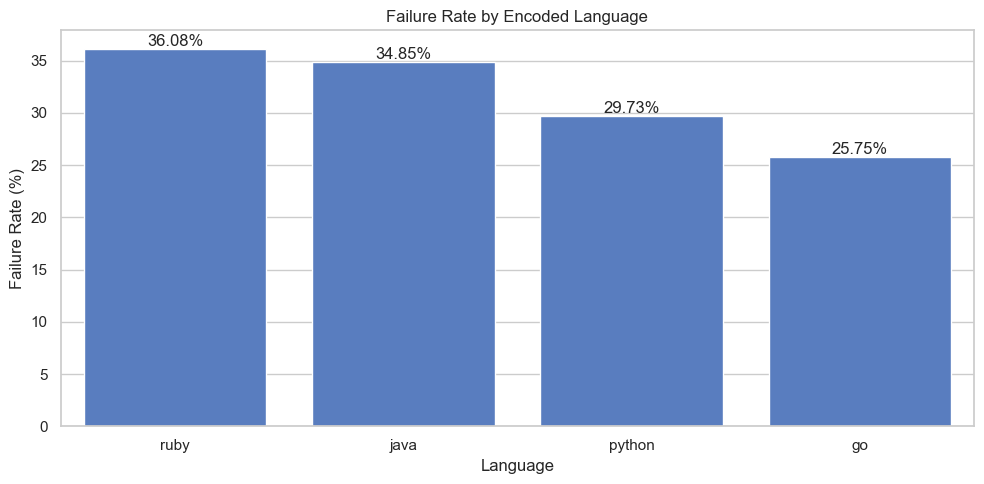

In [11]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=language_target, x='language', y='failure_rate_percent')
ax.set_title('Failure Rate by Encoded Language')
ax.set_xlabel('Language')
ax.set_ylabel('Failure Rate (%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

plt.tight_layout()
plt.show()

## 7. Boolean Feature Checks

In [12]:
bool_summary = []

for col in existing_bool_columns:
    counts = df[col].value_counts().reindex([0, 1], fill_value=0)
    bool_summary.append({
        'column': col,
        'zeros': counts.loc[0],
        'ones': counts.loc[1],
        'one_percent': round(counts.loc[1] / counts.sum() * 100, 2),
    })

bool_summary = pd.DataFrame(bool_summary)
bool_summary

,column,zeros,ones,one_percent
0,gh_is_pr,225891,24109,9.64
1,gh_by_core_team_member,28774,221226,88.49
2,tr_log_bool_tests_ran,49262,200738,80.30
3,is_weekend,200067,49933,19.97
4,is_large_commit,232668,17332,6.93


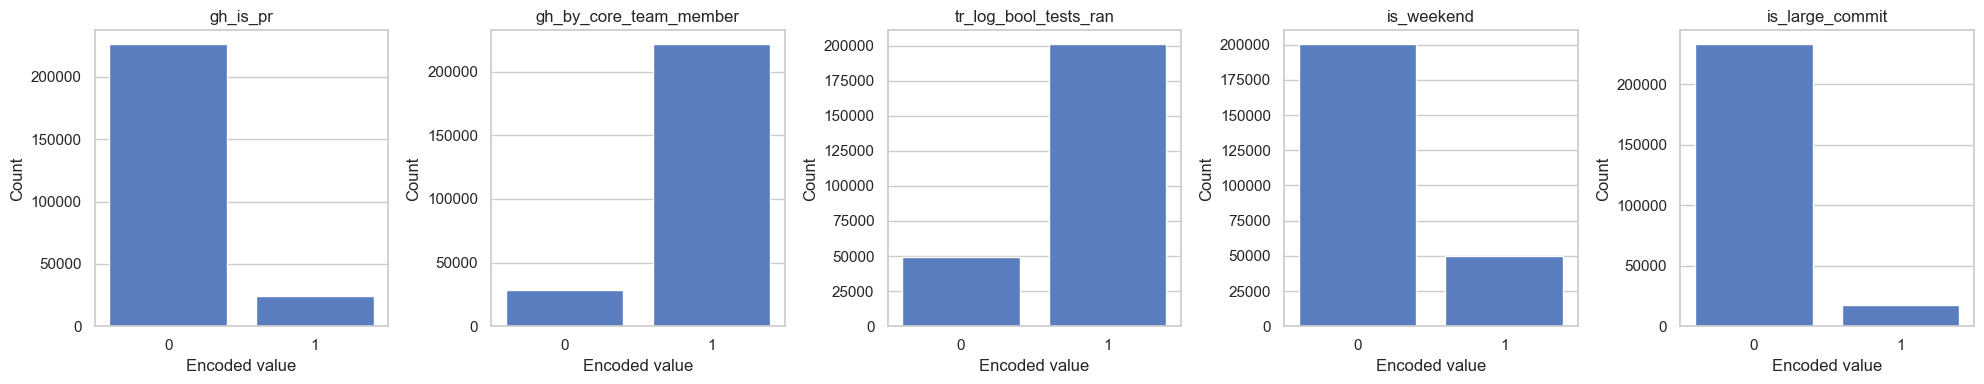

In [13]:
fig, axes = plt.subplots(1, len(existing_bool_columns), figsize=(4 * len(existing_bool_columns), 4))

if len(existing_bool_columns) == 1:
    axes = [axes]

for ax, col in zip(axes, existing_bool_columns):
    sns.countplot(data=df, x=col, order=[0, 1], ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Encoded value')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

## 8. Key Numeric Feature Distributions

In [14]:
numeric_features = [
    'tr_duration',
    'gh_team_size',
    'git_diff_src_churn',
    'git_diff_test_churn',
    'total_code_churn',
    'test_to_src_ratio',
    'total_files_changed',
    'test_fail_ratio',
    'project_failure_rate',
]

numeric_features = [col for col in numeric_features if col in df.columns]
df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
tr_duration,250000.0,1957.495200,2757.006197,0.0,484.750000,1204.000000,2455.000000,225950.0
gh_team_size,250000.0,19.249296,18.040516,0.0,6.000000,13.000000,25.000000,140.0
git_diff_src_churn,250000.0,1.255464,18.452757,0.0,0.000000,0.000000,0.000000,3398.0
git_diff_test_churn,250000.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0
total_code_churn,250000.0,1.255464,18.452757,0.0,0.000000,0.000000,0.000000,3398.0
test_to_src_ratio,250000.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0
total_files_changed,250000.0,5.649344,38.250359,0.0,1.000000,2.000000,4.000000,8022.0
test_fail_ratio,250000.0,0.010076,0.077429,0.0,0.000000,0.000000,0.000000,1.0
project_failure_rate,250000.0,0.353176,0.214852,0.0,0.202778,0.300748,0.481166,1.0


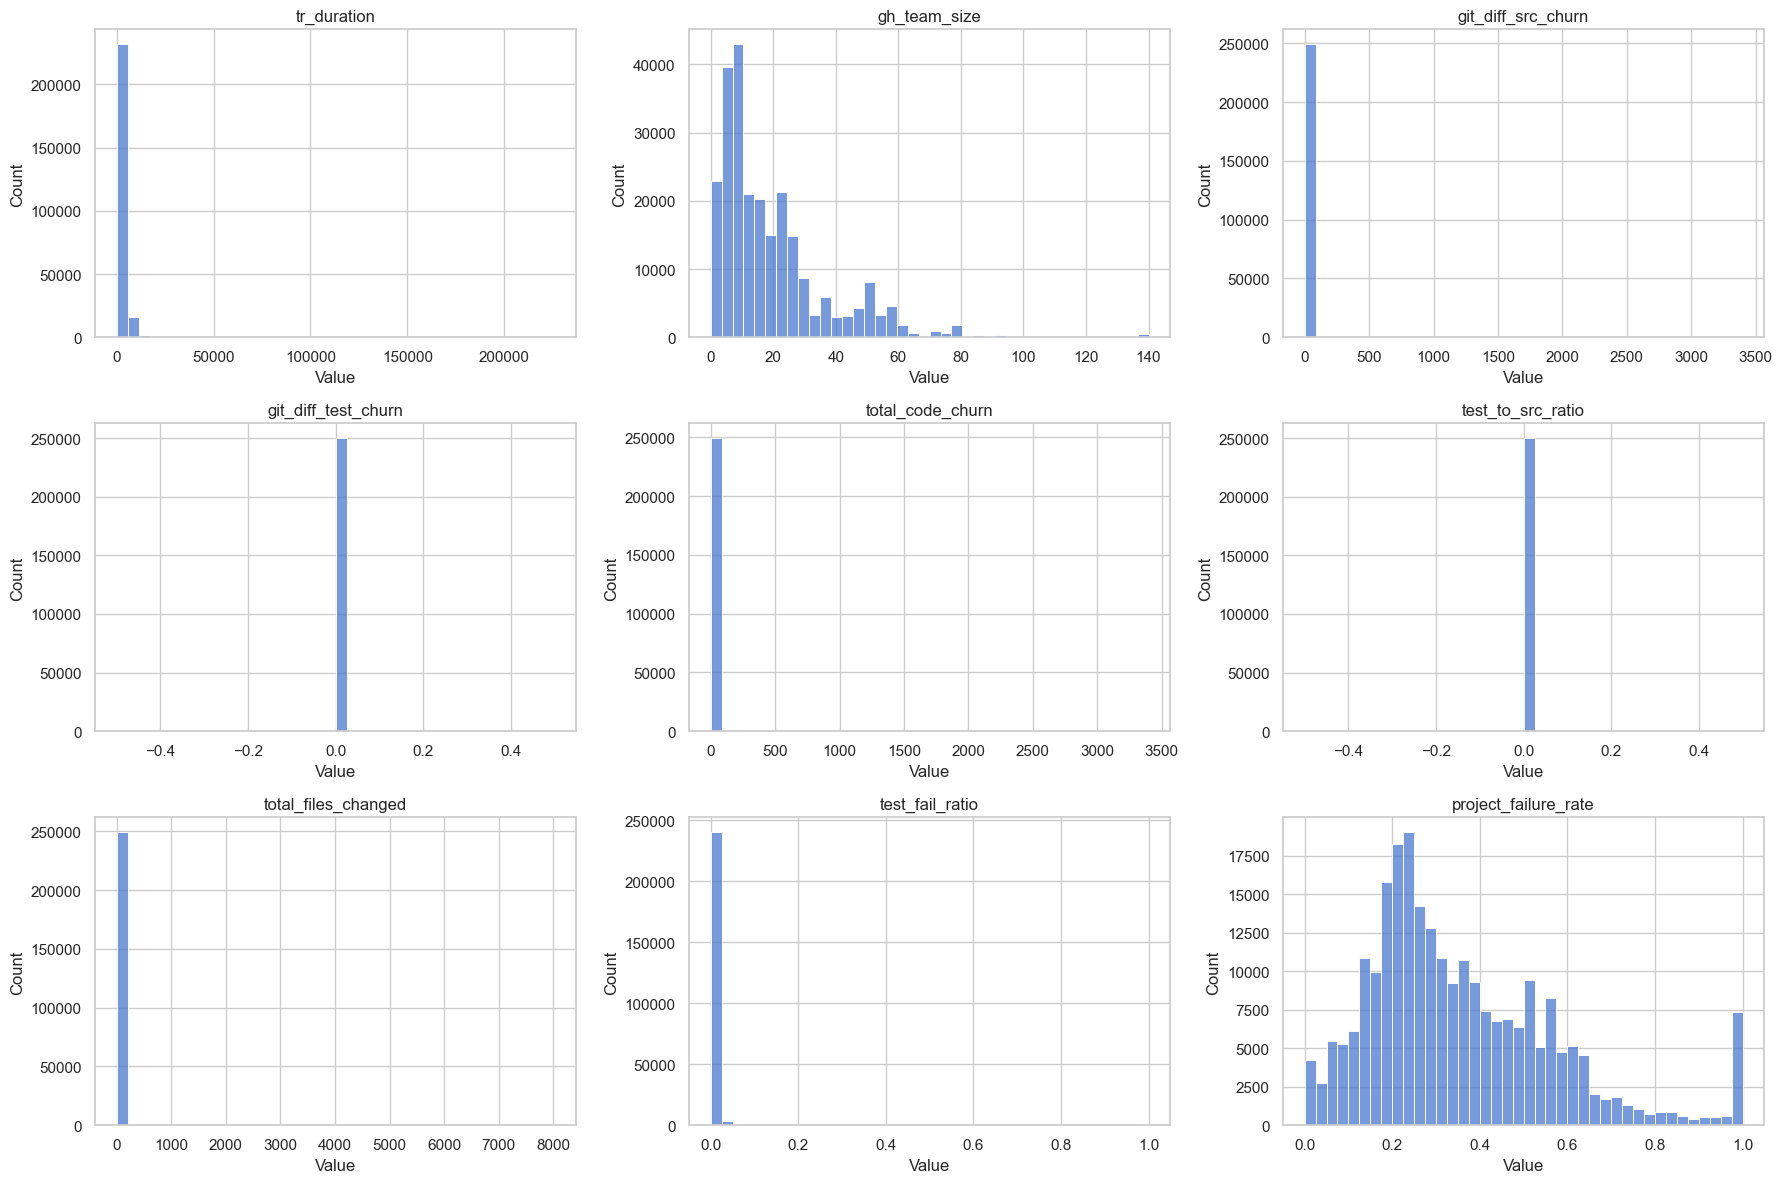

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, col in zip(axes, numeric_features):
    sns.histplot(df[col].replace([np.inf, -np.inf], np.nan).dropna(), bins=40, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

for ax in axes[len(numeric_features):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## 9. Correlation After Encoding

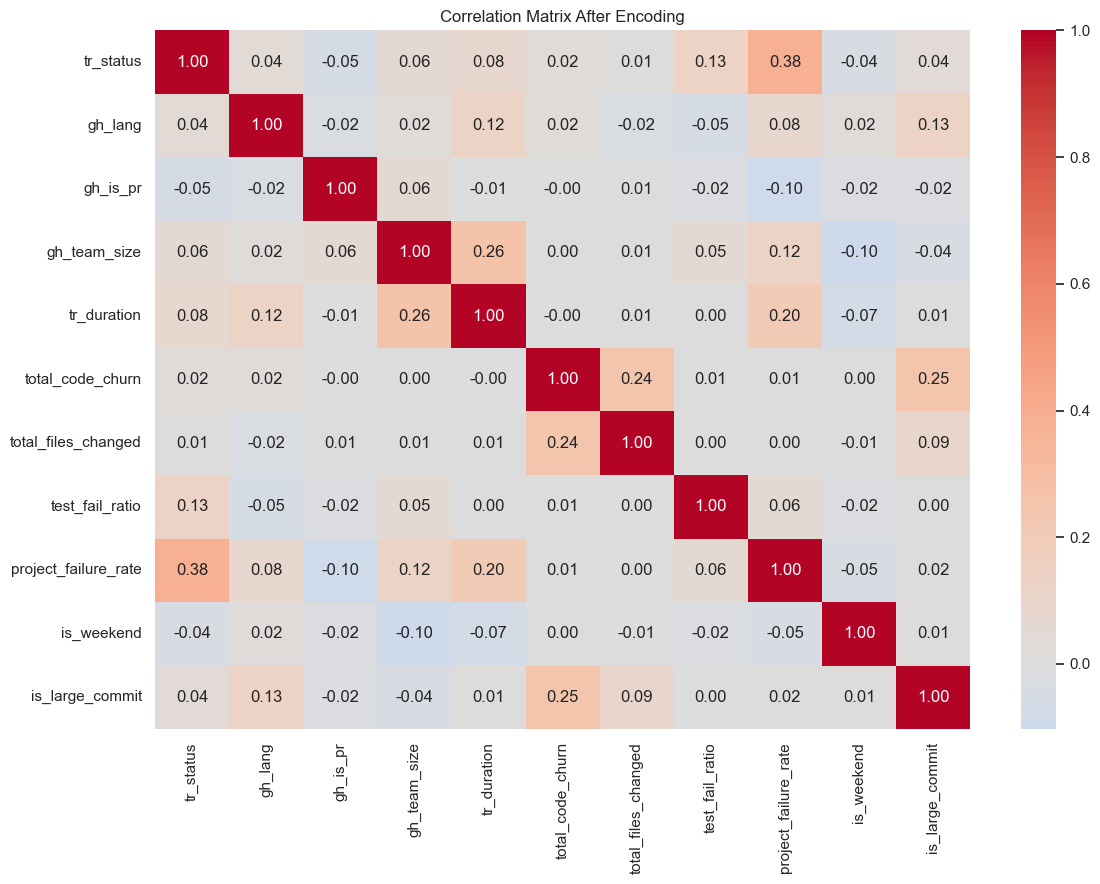

In [16]:
corr_features = [
    'tr_status',
    'gh_lang',
    'gh_is_pr',
    'gh_team_size',
    'tr_duration',
    'total_code_churn',
    'total_files_changed',
    'test_fail_ratio',
    'project_failure_rate',
    'is_weekend',
    'is_large_commit',
]

corr_features = [col for col in corr_features if col in df.columns]
corr = df[corr_features].corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix After Encoding')
plt.tight_layout()
plt.show()

## 10. Missing Values After Encoding

In [17]:
missing = (
    df.isna().sum()
      .to_frame('missing_count')
      .assign(missing_percent=lambda x: (x['missing_count'] / len(df) * 100).round(2))
      .query('missing_count > 0')
      .sort_values('missing_percent', ascending=False)
)

missing

,missing_count,missing_percent


## Summary

This notebook checks that the encoding phase produced one encoded dataset and that the encoded columns are ready for the next preprocessing/model-preparation step.

**Next step:** dataset splitting and scaling should happen in the model-preparation/training phase, so the scaler can be fitted on the training data only.